# Laboratório 2 – Extração de Características (Features)
# Visão Computacional — 2026.2

---

**Autores:**
 - João Victor de Castro Carvalho RA 11202420287
 - Mario Guerreiro Cerconvis RA 11202421459
 - Marco Antonio Silva da Mata 11202320279
 - João Victor Gonçalves Nascimento RA 11202420821

**Data de realização dos experimentos:** 14 de Junho de 2026

**Data de publicação do relatório:** 14 de Junho de 2026

---

## 1. Introdução

Este relatório apresenta os estudos e experimentos realizados no Laboratório 2 da disciplina Visão Computacional, cujo tema central é a **extração de características (features)** em imagens digitais.

A detecção e descrição de features é um dos pilares fundamentais da visão computacional moderna, sendo utilizada em aplicações como:
- Reconhecimento de objetos
- Rastreamento de movimento
- Construção de panoramas (image stitching)
- Reconstrução 3D
- Navegação autônoma (SLAM)
- Realidade aumentada

Neste laboratório, estudamos os conceitos teóricos dos detectores de **Harris**, **Shi-Tomasi** e **SIFT**, e realizamos experimentos práticos de **Feature Matching com Homografia** utilizando o algoritmo SIFT (Scale-Invariant Feature Transform) do OpenCV.

O relatório está organizado da seguinte forma:
1. **Fundamentação Teórica** — introdução aos detectores e descritores estudados
2. **Procedimentos Experimentais** — detalhamento dos experimentos realizados
3. **Análise e Discussão** — análise dos resultados e aplicações
4. **Conclusões** — síntese dos aprendizados
5. **Referências** — fontes consultadas

## 2. Fundamentação Teórica

### 2.1 O que são Features?

Para entender o conceito de features, considere um exemplo simples: temos uma imagem e queremos encontrar exatamente a mesma região em outra imagem. Dependendo da região escolhida, a busca pode ser mais fácil ou mais difícil.

Regiões planas são ruins para essa tarefa: como a intensidade é constante em todas as direções, não há como determinar com precisão onde elas estão — qualquer ponto serve. Bordas já são melhores, pois reduzem a ambiguidade a apenas uma direção. Porém, o melhor tipo de feature é o **canto**, pois eles são únicos no sentido de que a variação de intensidade é grande em todas as direções, o que torna possível encontrá-los de forma exata.

Por isso, cantos são considerados boas features em visão computacional.

---

### 2.2 Detector de Harris

O Detector de Harris foi desenvolvido para identificar esses cantos de forma matemática. A ideia é: ao mover uma janela de busca em qualquer direção sobre um ponto, a variação de intensidade deve ser grande — e isso caracteriza um canto.

Essa variação é expressa por:

$$E(u,v) = \sum_{x,y} w(x,y)\,[I(x+u,\,y+v) - I(x,y)]^2$$

onde $w(x,y)$ é a função janela, $I$ é a imagem e $(u,v)$ é o deslocamento. Para detectar cantos, queremos maximizar $E(u,v)$.

No final, é dada uma pontuação que indica se a janela contém um canto ou não:

$$R = \det(M) - k\cdot(\text{trace}(M))^2$$

- $|R|$ pequeno → região plana
- $R < 0$ → borda
- $R > 0$ (grande) → **canto**

No OpenCV, a função utilizada é `cv2.cornerHarris(img, blockSize, ksize, k)`, onde `blockSize` é o tamanho da vizinhança, `ksize` é o parâmetro do operador Sobel e `k` é a constante de Harris.

---

### 2.3 Detector de Shi-Tomasi

Shi-Tomasi propôs uma modificação ao detector de Harris: em vez de usar a função $R$ original, usa-se diretamente o menor autovalor da matriz $M$:

$$R = \min(\lambda_1,\, \lambda_2)$$

Se esse valor for maior que um certo limiar, o ponto é considerado um canto. Essa abordagem produz resultados melhores que os do Harris.

No OpenCV, a função é `cv2.goodFeaturesToTrack(img, maxCorners, qualityLevel, minDistance)`. Ela retorna os $N$ melhores cantos da imagem, sendo amplamente usada para rastreamento de pontos em vídeo.

---

### 2.4 Introdução ao SIFT

Os métodos de Harris e Shi-Tomasi são afetados pela escala: um canto detectado em uma imagem pode não ser reconhecido se ela for ampliada ou reduzida. O **SIFT** (Scale-Invariant Feature Transform) resolve esse problema.

O SIFT opera em quatro etapas:

1. **Detecção de extremos no espaço de escala:** a imagem é convoluída com filtros Gaussianos em diferentes escalas, formando uma pirâmide. A Diferença de Gaussianas (DoG) é calculada entre escalas adjacentes. Pontos que são máximos ou mínimos locais nesse espaço são candidatos a keypoints.

2. **Filtragem e localização dos keypoints:** pontos com baixo contraste ou localizados sobre bordas são descartados. A localização é refinada para precisão subpixel.

3. **Atribuição de orientação:** para garantir que o ponto seja reconhecido mesmo se a imagem for girada, o algoritmo analisa o gradiente ao redor do keypoint. Ele monta um histograma de orientações, e a direção que mais aparece é "carimbada" no keypoint.

4. **Geração do descritor:** uma região $16 \times 16$ ao redor do keypoint é dividida em blocos $4 \times 4$. Em cada bloco, calcula-se um histograma de 8 orientações, resultando em um vetor de **128 dimensões**. Esse vetor é normalizado para robustez a variações de iluminação.

No OpenCV, o SIFT é criado com `cv2.SIFT_create()` e os keypoints e descritores são obtidos com `sift.detectAndCompute(img, None)`.

## 3. Procedimentos Experimentais

### 3.0 Configuração do Ambiente

Primeiramente, importamos as bibliotecas necessárias e configuramos o ambiente de visualização.

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Configuração para exibir imagens no notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

OpenCV version: 4.13.0
NumPy version: 2.4.6


### 3.1 Parte 2A: Feature Matching + Homography to find Objects

Seguindo o tutorial do OpenCV, utilizamos SIFT para detectar features em duas imagens,

Referência: <https://docs.opencv.org/4.x/d1/de0/tutorial_py_feature_homography.html>

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

MIN_MATCH_COUNT = 10

img1 = cv.imread('imagens/cena1.png', cv.IMREAD_GRAYSCALE)  # queryImage
img2 = cv.imread('imagens/cena2.png', cv.IMREAD_GRAYSCALE)  # trainImage

# Initiate SIFT detector
sift = cv.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(des1, des2, k=2)

# store all the good matches as per Lowe's ratio test.
good = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good.append(m)

if len(good) > MIN_MATCH_COUNT:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
    matchesMask = mask.ravel().tolist()

    h, w = img1.shape
    pts = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
    dst = cv.perspectiveTransform(pts, M)

    img2 = cv.polylines(img2, [np.int32(dst)], True, 255, 3, cv.LINE_AA)

else:
    print("Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT))
    matchesMask = None

draw_params = dict(matchColor=(0, 255, 0),
                   singlePointColor=None,
                   matchesMask=matchesMask,
                   flags=2)

img3 = cv.drawMatches(img1, kp1, img2, kp2, good, None, **draw_params)

plt.figure(figsize=(16, 8))
plt.imshow(img3, 'gray')
plt.title(f'Feature Matching + Homography — {sum(matchesMask)} inliers de {len(good)} matches')
plt.axis('off')
plt.savefig('imagens/resultado_matching_cenas.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Parte 2B: SIFT Matching em Tempo Real com Webcams

O código abaixo implementa a correspondência SIFT em tempo real utilizando duas webcams (ou duas fontes de vídeo). nosso grupo também disponibilizou o modulo python sift_webcam.py para realizar a mesma tarefa. Pressione 'q' para sair e 's' para salvar um frame.

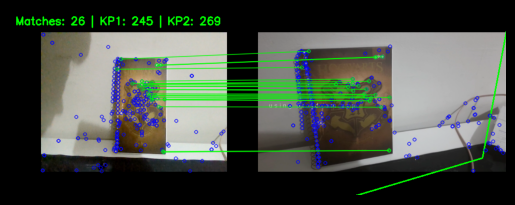

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def sift_webcam_matching():
    cap1 = cv2.VideoCapture(0)
    cap2 = cv2.VideoCapture(2)

    if not cap1.isOpened() or not cap2.isOpened():
        print("Erro: Não foi possível abrir as webcams.")
        print("Verifique se duas webcams estão conectadas.")
        if cap1.isOpened():
            print("Usando webcam 1 para ambos os feeds (modo demonstração).")
            cap2 = cap1
        else:
            return

    sift = cv2.SIFT_create()

    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    print("Pressione 'q' para sair.")
    print("Pressione 's' para salvar um frame.")

    frame_count = 0

    while True:
        ret1, frame1 = cap1.read()
        ret2, frame2 = cap2.read()

        if not ret1 or not ret2:
            print("Erro ao capturar frame.")
            break

        frame1 = cv2.resize(frame1, (480, 360))
        frame2 = cv2.resize(frame2, (480, 360))

        gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

        kp1, des1 = sift.detectAndCompute(gray1, None)
        kp2, des2 = sift.detectAndCompute(gray2, None)

        if des1 is not None and des2 is not None and len(des1) > 2 and len(des2) > 2:
            matches = flann.knnMatch(des1, des2, k=2)

            good_matches = []
            for m, n in matches:
                if m.distance < 0.7 * n.distance:
                    good_matches.append(m)

            MIN_MATCH_COUNT = 10

            if len(good_matches) >= MIN_MATCH_COUNT:
                src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
                dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

                M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

                if M is not None:
                    matchesMask = mask.ravel().tolist()

                    h, w = gray1.shape
                    pts = np.float32([[0,0],[0,h-1],[w-1,h-1],[w-1,0]]).reshape(-1,1,2)
                    dst = cv2.perspectiveTransform(pts, M)
                    frame2_display = frame2.copy()
                    cv2.polylines(frame2_display, [np.int32(dst)], True, (0,255,0), 2)
                else:
                    matchesMask = None
                    frame2_display = frame2
            else:
                matchesMask = None
                frame2_display = frame2

            draw_params = dict(
                matchColor=(0, 255, 0),
                singlePointColor=(255, 0, 0),
                matchesMask=matchesMask,
                flags=0
            )

            result = cv2.drawMatches(frame1, kp1, frame2_display, kp2,
                                     good_matches, None, **draw_params)

            info_text = f"Matches: {len(good_matches)} | KP1: {len(kp1)} | KP2: {len(kp2)}"
            cv2.putText(result, info_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                       0.7, (0, 255, 0), 2)
        else:
            result = np.hstack([frame1, frame2])
            cv2.putText(result, "Sem features detectadas", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

        cv2.imshow("SIFT Matching - Webcams", result)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('s'):
            cv2.imwrite(f"imagens/webcam_match_{frame_count}.png", result)
            print(f"Frame salvo: imagens/webcam_match_{frame_count}.png")
            img = mpimg.imread(f"imagens/webcam_match_{frame_count}.png")
            plt.imshow(img)
            plt.axis('off')
            plt.show()
            frame_count += 1

    cap1.release()
    if cap2 != cap1:
        cap2.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    sift_webcam_matching()

# 4. Análise e Discussão

A detecção de features é amplamente utilizada em aplicações de Visão Computacional, como reconhecimento de objetos, realidade aumentada, robótica e sistemas de navegação. Algoritmos como SIFT permitem identificar pontos característicos em imagens e encontrar correspondências mesmo quando há mudanças de escala, rotação ou perspectiva.

Diversos trabalhos científicos e projetos desenvolvidos com OpenCV utilizam detecção de features para reconhecimento de objetos em tempo real. Essas técnicas são especialmente úteis em sistemas de assistência para pessoas com deficiência visual, permitindo identificar objetos e pontos de referência presentes no ambiente.

No contexto do trabalho final, a detecção de features poderia ser utilizada para reconhecer objetos do cotidiano, como portas, placas de sinalização, embalagens de medicamentos ou outros elementos importantes para a orientação do usuário. Após a identificação do objeto pela câmera, o sistema poderia fornecer um retorno por áudio, auxiliando na percepção do ambiente.

Os resultados obtidos durante os testes demonstram que a técnica possui potencial para aplicações de acessibilidade, sendo uma alternativa eficiente para reconhecimento visual sem a necessidade de treinamento de modelos complexos de inteligência artificial.


## 5. Conclusões

Neste laboratório, estudamos e implementamos com sucesso as principais técnicas de detecção e descrição de features em visão computacional:

1. **Fundamentação teórica**: Compreendemos os princípios matemáticos dos detectores de Harris, Shi-Tomasi e SIFT, entendendo suas diferenças em termos de invariância, custo computacional e aplicabilidade.

2. **Feature Matching com Homografia**: Implementamos o pipeline completo do OpenCV para correspondência de features entre imagens, incluindo:
   - Detecção de keypoints SIFT
   - Matching com FLANN
   - Filtragem com teste de razão de Lowe
   - Estimação de homografia com RANSAC
   - Projeção de contornos para detecção de objetos

3. **Matching em tempo real**: Desenvolvemos um script para correspondência SIFT em tempo real com duas webcams, demonstrando a viabilidade do pipeline para aplicações interativas.

4. **Análise de aplicações**: Identificamos diversas aplicações práticas das técnicas estudadas, desde reconhecimento de objetos até SLAM e realidade aumentada.

O SIFT demonstrou ser um algoritmo robusto e versátil para extração de características, sendo fundamental para diversas aplicações em visão computacional. Embora algoritmos mais recentes como ORB e AKAZE ofereçam melhor desempenho computacional, o SIFT continua sendo referência pela qualidade de suas correspondências.

## 6. Referências

1. **Harris, C.; Stephens, M.** (1988). "A Combined Corner and Edge Detector." *Proceedings of the Alvey Vision Conference*, pp. 147–151.

2. **Shi, J.; Tomasi, C.** (1994). "Good Features to Track." *IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*, pp. 593–600.

3. **Lowe, D. G.** (2004). "Distinctive Image Features from Scale-Invariant Keypoints." *International Journal of Computer Vision*, 60(2), pp. 91–110.

4. **Brown, M.; Lowe, D. G.** (2007). "Automatic Panoramic Image Stitching using Invariant Features." *International Journal of Computer Vision*, 74(1), pp. 59–73.

5. **Bay, H.; Ess, A.; Tuytelaars, T.; Van Gool, L.** (2008). "Speeded-Up Robust Features (SURF)." *Computer Vision and Image Understanding*, 110(3), pp. 346–359.

6. **Mur-Artal, R.; Montiel, J. M. M.; Tardós, J. D.** (2015). "ORB-SLAM: A Versatile and Accurate Monocular SLAM System." *IEEE Transactions on Robotics*, 31(5), pp. 1147–1163.

7. **OpenCV Documentation** — Feature Detection and Description. Disponível em: <https://docs.opencv.org/4.x/db/d27/tutorial_py_table_of_contents_feature2d.html>

8. **OpenCV Tutorial** — Feature Matching + Homography to find Objects. Disponível em: <https://docs.opencv.org/4.x/d1/de0/tutorial_py_feature_homography.html>

9. **SZELISKI, R. *Computer Vision: Algorithms and Applications*, 2022.